Import libraries

In [117]:
import PIL.Image as image
import numpy as np
import matplotlib.pyplot as plt

Load grayscale image

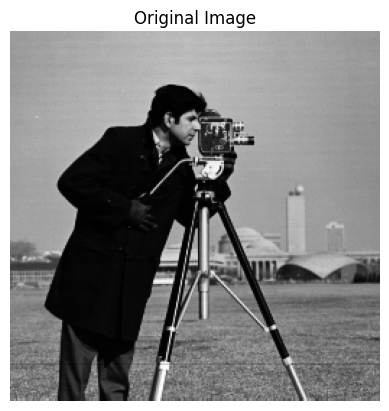

In [118]:
img = image.open("images/cameraman.tif").convert("L")
img = np.array(img)

H, W = img.shape

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

Laplacian filter

In [119]:
filter = np.array([[0,  1,  0],
                   [1, -4,  1],
                   [0,  1,  0]])

Replicate Padding

In [121]:
padded_img = np.pad(img, pad_width=1, mode='edge')

Apply the laplacian filter

In [ ]:

laplacian_edges = np.zeros_like(img, dtype=float)


for i in range(H):
    for j in range(W):
        region = padded_img[i:i+3, j:j+3]
        laplacian_edges[i, j] = np.sum(region * filter)

sharpen_image = img - laplacian_edges

laplacian_edges = np.clip(laplacian_edges, 0, 255).astype(np.uint8)

sharpen_image = np.clip(sharpen_image, 0, 255).astype(np.uint8)

Laplacian filter results

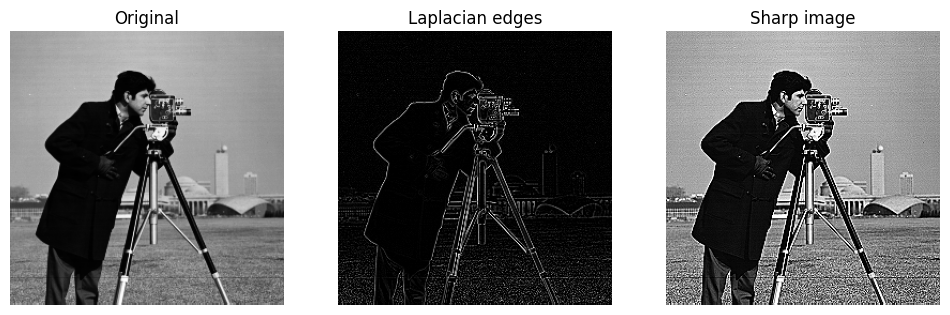

In [128]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(laplacian_edges, cmap='gray')
plt.title("Laplacian edges")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sharpen_image, cmap='gray')
plt.title("Sharp image")
plt.axis("off")

plt.show()

Sobel filter

In [ ]:
sobel_x = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

sobel_y = np.array([[-1,  0,  1],
                    [-2,  0,  2],
                    [-1,  0,  1]])

Apply the sobel filter

In [130]:
gx = np.zeros_like(img, dtype=float)
gy = np.zeros_like(img, dtype=float)

for i in range(H):
    for j in range(W):
        region = padded_img[i:i+3, j:j+3]
        gx[i, j] = np.sum(region * sobel_x)
        gy[i, j] = np.sum(region * sobel_y)

sobel = np.abs(gx) + np.abs(gy)

gx = np.clip(gx, 0, 255).astype(np.uint8)
gy = np.clip(gy, 0, 255).astype(np.uint8)

sobel = np.clip(sobel, 0, 255).astype(np.uint8)

Sobel filter results

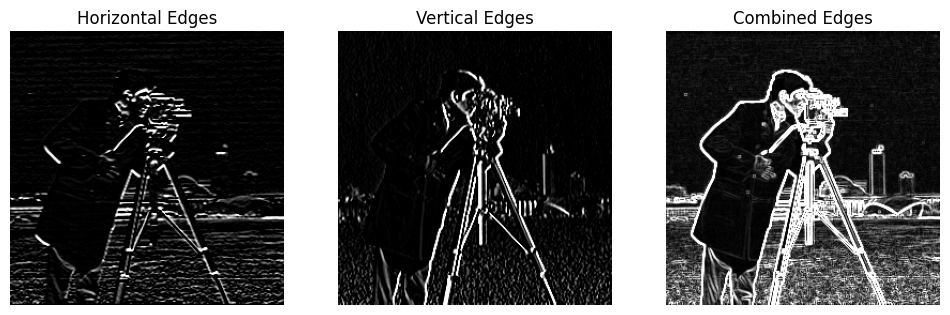

In [131]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(gx, cmap='gray')
plt.title("Horizontal Edges")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gy, cmap='gray')
plt.title("Vertical Edges")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sobel, cmap='gray')
plt.title("Combined Edges")
plt.axis("off")

plt.show()